# Import Libraries

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix,accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_predict, cross_validate
from sklearn.metrics import make_scorer
from sklearn.model_selection import KFold
from sklearn.base import clone

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# Load Data

In [2]:
train = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
test = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")
print('train data:', train.shape)
print('test data:', test.shape)

train data: (891, 12)
test data: (418, 11)


In [3]:
train.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# EDA

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
train.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [6]:
train.duplicated().sum()

np.int64(0)

In [7]:
train.isnull().sum().sort_values(ascending = False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

In [8]:
col_numerical = train.select_dtypes(include=[np.number])
col_numerical.head(5)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


In [9]:
col_numerical.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
def print_nunique_var(columns):
    for col in columns:
        if train[col].nunique()<= 10:
            print(col, ':', train[col].unique())

print_nunique_var(col_numerical)

Survived : [0 1]
Pclass : [3 1 2]
SibSp : [1 0 3 4 2 5 8]
Parch : [0 1 2 5 3 4 6]


In [11]:
col_categorical = train.select_dtypes(exclude=[np.number])
col_categorical.head(5)

,Name,Sex,Ticket,Cabin,Embarked
0,"Braund, Mr. Owen Harris",male,A/5 21171,NaN,S
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,C85,C
2,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,NaN,S
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,C123,S
4,"Allen, Mr. William Henry",male,373450,NaN,S


In [12]:
print_nunique_var(col_categorical)

Sex : ['male' 'female']
Embarked : ['S' 'C' 'Q' nan]


In [13]:
print(f"Embarked mode: {col_categorical['Embarked'].mode()[0]}")

Embarked mode: S


## Target Distribution

In [14]:
counts = train['Survived'].value_counts()
percentage = ((train['Survived'].value_counts()/len(train)) * 100)

dist_survived = pd.DataFrame({
    'Passangers' : counts,
    'Porcentaje' : percentage,
}) 

dist_survived

,Passangers,Porcentaje
Survived,,
0,549,61.616162
1,342,38.383838


## Variables Distribution

<Figure size 1200x800 with 0 Axes>

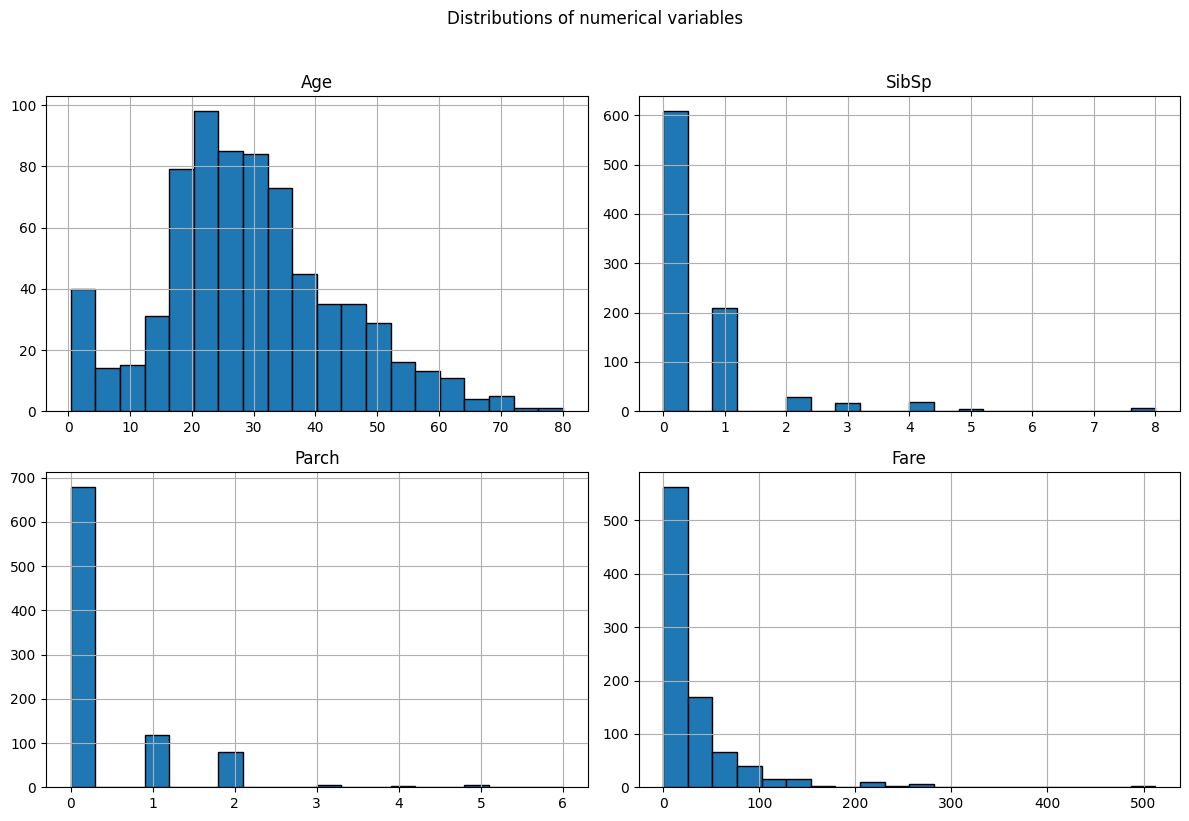

In [15]:
plt.figure(figsize=(12, 8))
col_numerical.iloc[:, 3:].hist(figsize=(12, 8), bins=20, edgecolor="black")
plt.suptitle("Distributions of numerical variables", y=1.02)
plt.tight_layout()
plt.show()

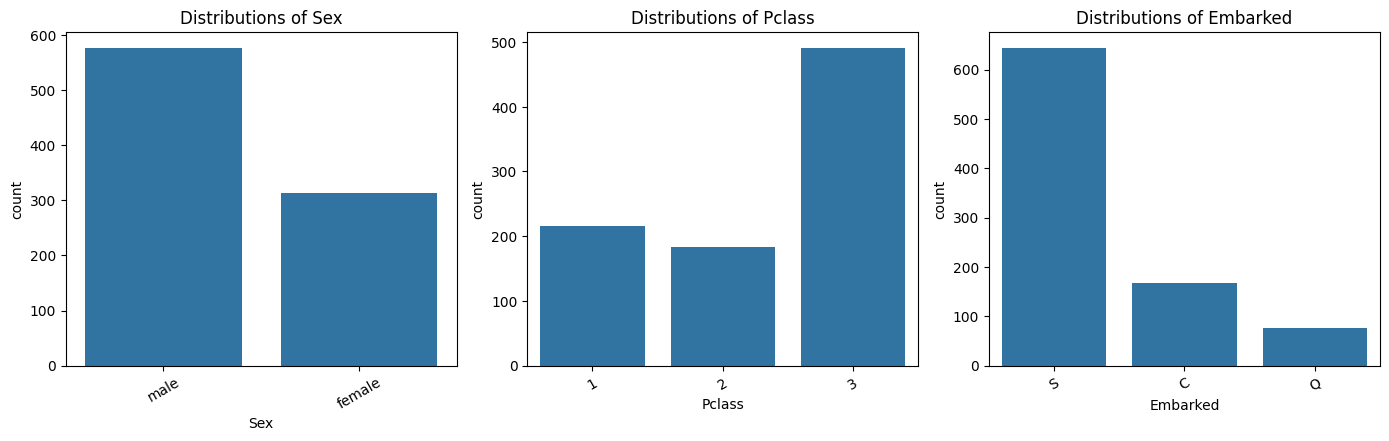

In [16]:
plt.figure(figsize=(14, 8))
plot_cols = plot_cols = ["Sex", "Pclass", "Embarked"]
for i, col in enumerate(plot_cols, 1):
    if col in train.columns:
        plt.subplot(2, 3, i)
        sns.countplot(x=col, data=train)
        plt.title(f"Distributions of {col}")
        plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

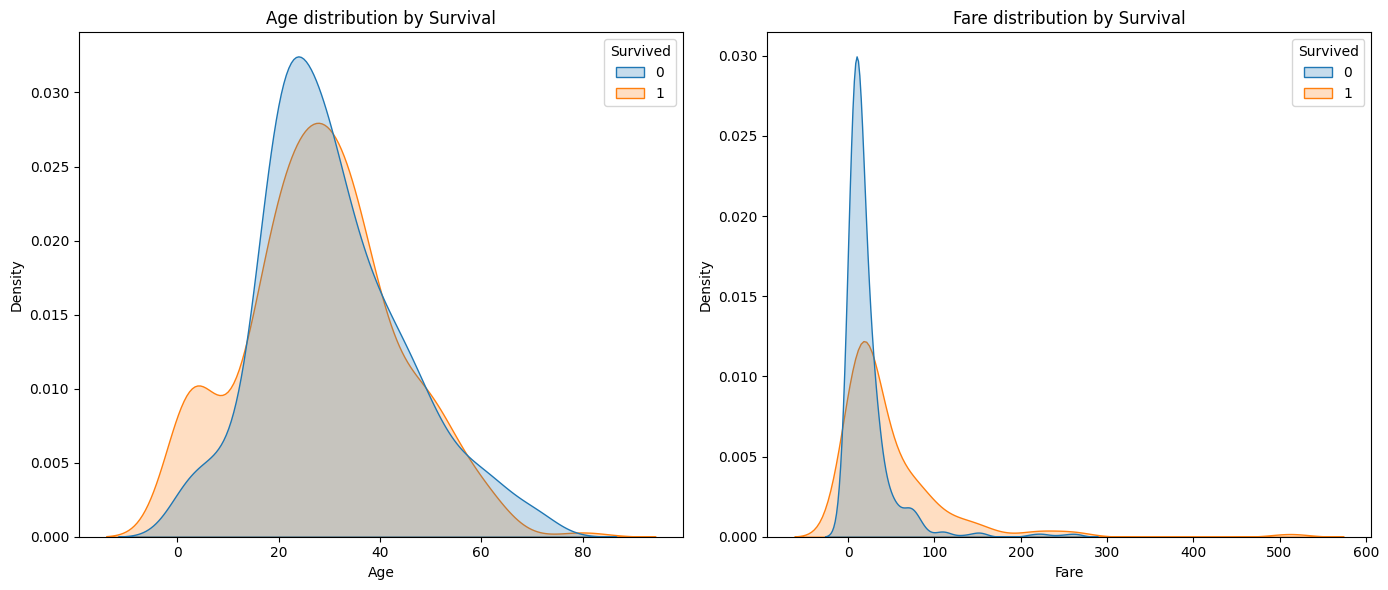

In [17]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.kdeplot(data=train, x="Age", hue="Survived", common_norm=False, fill=True)
plt.title("Age distribution by Survival")

plt.subplot(1, 2, 2)
sns.kdeplot(data=train, x="Fare", hue="Survived", common_norm=False, fill=True)
plt.title("Fare distribution by Survival")

plt.tight_layout()
plt.show()

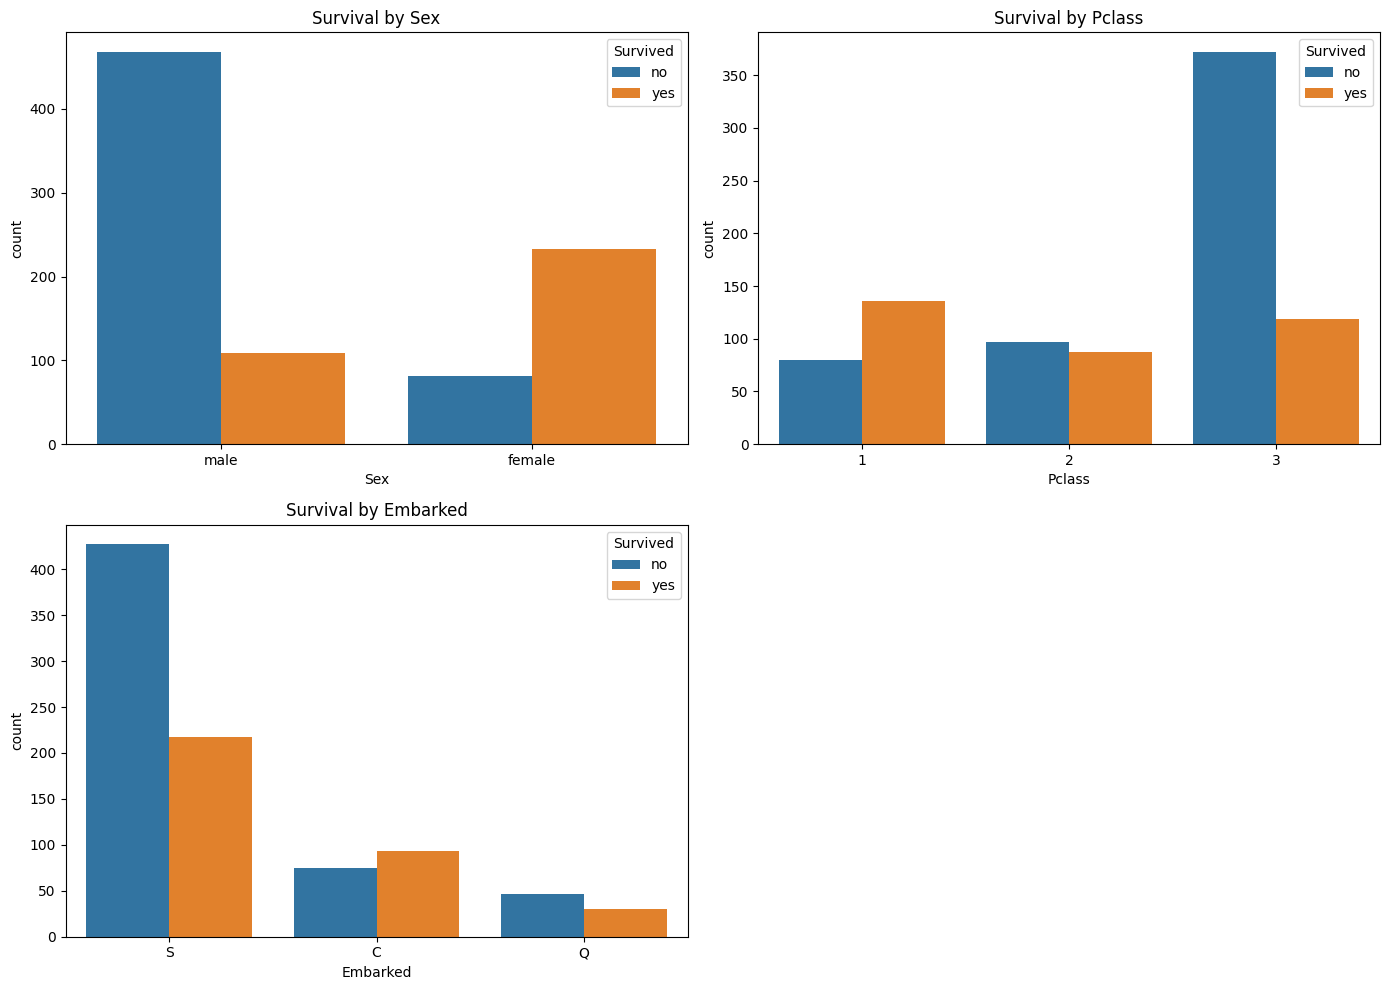

In [18]:
def plot_survival_by_categories(df, columns, labels=["no", "yes"]):
    n = len(columns)
    rows = math.ceil(n / 2)

    plt.figure(figsize=(14, 5 * rows))

    for i, col in enumerate(columns, 1):
        plt.subplot(rows, 2, i)
        sns.countplot(x=col, hue="Survived", data=df)
        plt.title(f"Survival by {col}")
        plt.legend(title="Survived", labels=labels)

    plt.tight_layout()
    plt.show()
    
plot_survival_by_categories(train, columns=["Sex", "Pclass", "Embarked"])

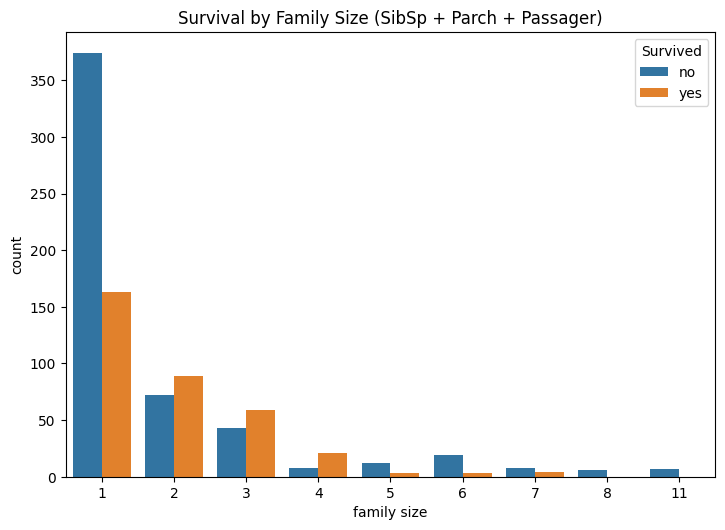

In [19]:
labels=["no", "yes"]
plt.figure(figsize=(14, 10))
plt.subplot(2, 2, 4)

# family size = siblings/spouses + parents/children + passenger
family_size = train["SibSp"] + train["Parch"] + 1
sns.countplot(x=family_size, hue=train["Survived"])
plt.title("Survival by Family Size (SibSp + Parch + Passager)")
plt.xlabel("family size")
plt.legend(title="Survived", labels=labels)

plt.tight_layout()
plt.show()

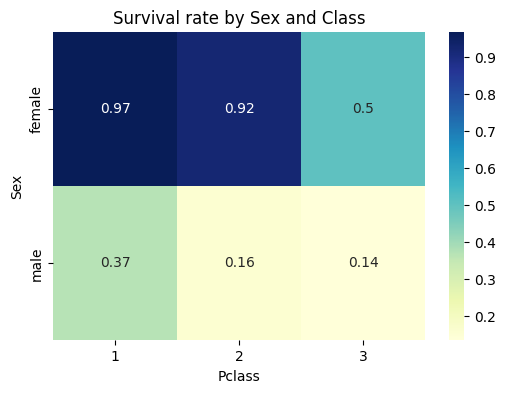

In [20]:
rate_sex_pclass = (
    train
    .groupby(["Sex", "Pclass"]) ["Survived"]
    .mean()
    .unstack()
)

plt.figure(figsize=(6, 4))
sns.heatmap(rate_sex_pclass, annot=True, cmap="YlGnBu") #fmt=".2f")
plt.title("Survival rate by Sex and Class")
plt.ylabel("Sex")
plt.xlabel("Pclass")
plt.show()

# Data Cleaning

In [21]:
titanic = train.copy()
titanic.sample(4)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
128,129,1,3,"Peter, Miss. Anna",female,NaN,1,1,2668,22.3583,F E69,C
806,807,0,1,"Andrews, Mr. Thomas Jr",male,39.0,0,0,112050,0.0000,A36,S
416,417,1,2,"Drew, Mrs. James Vivian (Lulu Thorne Christian)",female,34.0,1,1,28220,32.5000,NaN,S
210,211,0,3,"Ali, Mr. Ahmed",male,24.0,0,0,SOTON/O.Q. 3101311,7.0500,NaN,S


In [22]:
def embarked_imputation(data):
    df = data.copy()
    mode_embarked = df['Embarked'].mode()[0]
    df['Embarked'] = df['Embarked'].fillna(mode_embarked)
    return df

titanic = embarked_imputation(titanic)
titanic.sample(4)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
659,660,0,1,"Newell, Mr. Arthur Webster",male,58.0,0,2,35273,113.2750,D48,C
532,533,0,3,"Elias, Mr. Joseph Jr",male,17.0,1,1,2690,7.2292,NaN,C
175,176,0,3,"Klasen, Mr. Klas Albin",male,18.0,1,1,350404,7.8542,NaN,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S


In [23]:
def age_imputation(data):
    df = data.copy()
    age_median_by_group = df.groupby(["Sex", "Pclass"])["Age"].transform("median")
    df["Age"] = df["Age"].fillna(age_median_by_group)
    return df

titanic = age_imputation(titanic)
titanic.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


# Feature engineering

In [24]:
def featureEngineer_df(data):
    df = data.copy()
    df['familySize'] = df['SibSp'] + df['Parch'] + 1
    return df

titanic = featureEngineer_df(titanic)
titanic.sample(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,familySize
321,322,0,3,"Danoff, Mr. Yoto",male,27.0,0,0,349219,7.8958,NaN,S,1
843,844,0,3,"Lemberopolous, Mr. Peter L",male,34.5,0,0,2683,6.4375,NaN,C,1
211,212,1,2,"Cameron, Miss. Clear Annie",female,35.0,0,0,F.C.C. 13528,21.0000,NaN,S,1


# Preprocesing Data

In [25]:
def droping_features(data):
    df = data.copy()
    df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch'])
    df.sample(3)
    return df

titanic = droping_features(titanic)
titanic.sample(4)

,Survived,Pclass,Sex,Age,Fare,Embarked,familySize
112,0,3,male,22.0,8.05,S,1
121,0,3,male,25.0,8.05,S,1
890,0,3,male,32.0,7.75,Q,1
560,0,3,male,25.0,7.75,Q,1


In [26]:
def asCategory(list, df):
    for l in list:
        df[l] = df[l].astype('category')
    return df

catList = ['Sex','Embarked']
asCategory(catList, titanic)
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Survived    891 non-null    int64   
 1   Pclass      891 non-null    int64   
 2   Sex         891 non-null    category
 3   Age         891 non-null    float64 
 4   Fare        891 non-null    float64 
 5   Embarked    891 non-null    category
 6   familySize  891 non-null    int64   
dtypes: category(2), float64(2), int64(3)
memory usage: 36.9 KB


## Train Validation Split

In [27]:
X = titanic.drop(columns=['Survived'])
y = titanic['Survived']

In [28]:
print(X.head(3))
print(X.shape)

   Pclass     Sex   Age     Fare Embarked  familySize
0       3    male  22.0   7.2500        S           2
1       1  female  38.0  71.2833        C           2
2       3  female  26.0   7.9250        S           1
(891, 6)


## Preporcessor

In [29]:
preprocessor = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(sparse_output = False), catList),
        ('num', StandardScaler(),['Pclass', 'Age', 'Fare', 'familySize'])
        
    ]
)

# Hyperparameter Tuning

In [30]:
def evaluate_models(pipelines, X, y, n_splits=10):
    """
    Evaluate multiple models with stratified cross-validation.
    
    parameters:
        pipelines : dict  → {'name': model_or_pipeline}
        X         : df    → features
        y         : array → target
        n_splits  : int   → # of folds (default 10)
    """
    y_vec  = np.asarray(y).ravel()
    kfold  = StratifiedKFold(n_splits=n_splits, shuffle=True)

    def error_rate(y_true, y_pred):
        return 1 - accuracy_score(y_true, y_pred)

    metricas = {
        'accuracy'  : 'accuracy',
        'f1_macro'  : 'f1_macro',
        'error_rate': make_scorer(error_rate)
    }

    last_pipelines = {}
    for name, estimator in pipelines.items():
        if isinstance(estimator, Pipeline):
            last_pipelines[name] = estimator
        else:
            last_pipelines[name] = Pipeline(steps=[
                ('preprocessor', preprocessor),
                ('classifier',   estimator)
            ])

    # ========================================
    # Evaluation
    # ========================================
    resultados = {}
    for name, pipeline in last_pipelines.items():
        resultados[name] = cross_validate(
            estimator=pipeline,
            X=X,
            y=y_vec,
            cv=kfold,
            scoring=metricas,
            return_train_score=False
        )

    # ========================================
    # Report
    # ========================================
    for name, res in resultados.items():
        print(f"Model: {name}")
        print(f"  Accuracy  : {res['test_accuracy'].mean():.4f} ± {res['test_accuracy'].std():.4f}")
        print(f"  F1 macro  : {res['test_f1_macro'].mean():.4f} ± {res['test_f1_macro'].std():.4f}")
        print(f"  Error     : {res['test_error_rate'].mean():.4f} ± {res['test_error_rate'].std():.4f}")
        print()

    return last_pipelines

In [31]:
print(X.head(3))
print(X.shape)

   Pclass     Sex   Age     Fare Embarked  familySize
0       3    male  22.0   7.2500        S           2
1       1  female  38.0  71.2833        C           2
2       3  female  26.0   7.9250        S           1
(891, 6)


## SVC

In [32]:
pipelines = {
    'sigmoid': SVC(kernel='sigmoid', gamma='scale'),
    'rbf': SVC(kernel='rbf', gamma='scale'),
    'poly': SVC(kernel='poly', gamma='scale'),
}

noprint = evaluate_models(pipelines, X, y)

Model: sigmoid
  Accuracy  : 0.6846 ± 0.0308
  F1 macro  : 0.6670 ± 0.0324
  Error     : 0.3154 ± 0.0308

Model: rbf
  Accuracy  : 0.8272 ± 0.0215
  F1 macro  : 0.8098 ± 0.0236
  Error     : 0.1728 ± 0.0215

Model: poly
  Accuracy  : 0.8171 ± 0.0483
  F1 macro  : 0.7979 ± 0.0537
  Error     : 0.1829 ± 0.0483



In [33]:
m_svc = pipelines['rbf']

## KNN

In [34]:
pipelines = {
    'ball_tree': KNeighborsClassifier(n_neighbors=10, p=2, algorithm='ball_tree'),
    'kd_tree'  : KNeighborsClassifier(n_neighbors=10, p=2, algorithm='kd_tree'),
    'brute'    : KNeighborsClassifier(n_neighbors=10, p=2, algorithm='brute'),
}

results = evaluate_models(pipelines, X, y)

Model: ball_tree
  Accuracy  : 0.8103 ± 0.0268
  F1 macro  : 0.7894 ± 0.0302
  Error     : 0.1897 ± 0.0268

Model: kd_tree
  Accuracy  : 0.8025 ± 0.0328
  F1 macro  : 0.7823 ± 0.0373
  Error     : 0.1975 ± 0.0328

Model: brute
  Accuracy  : 0.8159 ± 0.0327
  F1 macro  : 0.7948 ± 0.0373
  Error     : 0.1841 ± 0.0327



In [35]:
m_knn = pipelines['ball_tree']

## DecisionTreeClassifier

In [36]:
pipelines = {
    'gini' : DecisionTreeClassifier(criterion='gini', max_depth=4, min_samples_leaf=6, class_weight='balanced'),
    'entropy' : DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_leaf=6, class_weight='balanced'),
    'log_loss' : DecisionTreeClassifier(criterion='log_loss', max_depth=4, min_samples_leaf=6, class_weight='balanced')
}

results = evaluate_models(pipelines, X, y)

Model: gini
  Accuracy  : 0.8069 ± 0.0445
  F1 macro  : 0.7931 ± 0.0467
  Error     : 0.1931 ± 0.0445

Model: entropy
  Accuracy  : 0.8103 ± 0.0279
  F1 macro  : 0.7960 ± 0.0268
  Error     : 0.1897 ± 0.0279

Model: log_loss
  Accuracy  : 0.8161 ± 0.0505
  F1 macro  : 0.8017 ± 0.0527
  Error     : 0.1839 ± 0.0505



In [37]:
m_tree = pipelines['gini']

## AdaBoostClassifier

In [38]:
estimator = DecisionTreeClassifier(criterion='gini', max_depth=4, min_samples_leaf=6, class_weight='balanced')
pipelines = {
    'md_1' : AdaBoostClassifier(n_estimators=21, learning_rate = 0.1, estimator = estimator),
    'md_2' : AdaBoostClassifier(n_estimators=21, learning_rate = 0.1, estimator = estimator),
    'md_3' : AdaBoostClassifier(n_estimators=21, learning_rate = 0.1, estimator = estimator),
}

results = evaluate_models(pipelines, X, y)

Model: md_1
  Accuracy  : 0.8237 ± 0.0489
  F1 macro  : 0.8096 ± 0.0552
  Error     : 0.1763 ± 0.0489

Model: md_2
  Accuracy  : 0.8194 ± 0.0388
  F1 macro  : 0.8034 ± 0.0455
  Error     : 0.1806 ± 0.0388

Model: md_3
  Accuracy  : 0.8215 ± 0.0314
  F1 macro  : 0.8074 ± 0.0338
  Error     : 0.1785 ± 0.0314



In [39]:
m_ada = pipelines['md_1']

## RandomForestClassifier

In [40]:
pipelines = {
    'gini' : RandomForestClassifier(n_estimators=100, criterion='gini', class_weight='balanced'),
    'entropy' : RandomForestClassifier(n_estimators=100, criterion='entropy', class_weight='balanced'),
    'log_loss' : RandomForestClassifier(n_estimators=100, criterion='log_loss', class_weight='balanced'),
}

results = evaluate_models(pipelines, X, y)

Model: gini
  Accuracy  : 0.8148 ± 0.0306
  F1 macro  : 0.8037 ± 0.0330
  Error     : 0.1852 ± 0.0306

Model: entropy
  Accuracy  : 0.8103 ± 0.0229
  F1 macro  : 0.7974 ± 0.0245
  Error     : 0.1897 ± 0.0229

Model: log_loss
  Accuracy  : 0.8081 ± 0.0384
  F1 macro  : 0.7957 ± 0.0417
  Error     : 0.1919 ± 0.0384



In [41]:
m_forest = pipelines['log_loss']

## GradientBoostingClassifier

In [42]:
pipelines = {
    'lr_005': GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, subsample=0.8),
    'lr_01':  GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,  max_depth=3, subsample=0.8),
    'lr_02':  GradientBoostingClassifier(n_estimators=100, learning_rate=0.2,  max_depth=3, subsample=0.8),
}

results = evaluate_models(pipelines, X, y)

Model: lr_005
  Accuracy  : 0.8249 ± 0.0396
  F1 macro  : 0.8088 ± 0.0434
  Error     : 0.1751 ± 0.0396

Model: lr_01
  Accuracy  : 0.8272 ± 0.0356
  F1 macro  : 0.8123 ± 0.0411
  Error     : 0.1728 ± 0.0356

Model: lr_02
  Accuracy  : 0.8273 ± 0.0405
  F1 macro  : 0.8135 ± 0.0443
  Error     : 0.1727 ± 0.0405



In [43]:
m_gradient = pipelines['lr_005']

## LinearDiscriminantAnalysis

In [44]:
pipelines = {
    'svd' : LinearDiscriminantAnalysis(solver = 'svd', shrinkage = None),
    'lsqr' : LinearDiscriminantAnalysis(solver = 'lsqr', shrinkage = 'auto'),
    'eigen' : LinearDiscriminantAnalysis(solver = 'eigen', shrinkage = 'auto'),
}

results = evaluate_models(pipelines, X, y)

Model: svd
  Accuracy  : 0.7991 ± 0.0461
  F1 macro  : 0.7836 ± 0.0502
  Error     : 0.2009 ± 0.0461

Model: lsqr
  Accuracy  : 0.7958 ± 0.0567
  F1 macro  : 0.7801 ± 0.0622
  Error     : 0.2042 ± 0.0567

Model: eigen
  Accuracy  : 0.7991 ± 0.0505
  F1 macro  : 0.7834 ± 0.0574
  Error     : 0.2009 ± 0.0505



In [45]:
m_lda = pipelines['lsqr']

## QuadraticDiscriminantAnalysis

In [46]:
pipelines = {
    'rp1' : QuadraticDiscriminantAnalysis(reg_param = 0.1),
    'rp3' : QuadraticDiscriminantAnalysis(reg_param = 0.3),
    'rp5' : QuadraticDiscriminantAnalysis(reg_param = 0.5),
}

results = evaluate_models(pipelines, X, y)

Model: rp1
  Accuracy  : 0.7947 ± 0.0325
  F1 macro  : 0.7698 ± 0.0405
  Error     : 0.2053 ± 0.0325

Model: rp3
  Accuracy  : 0.7980 ± 0.0176
  F1 macro  : 0.7699 ± 0.0228
  Error     : 0.2020 ± 0.0176

Model: rp5
  Accuracy  : 0.7733 ± 0.0340
  F1 macro  : 0.7344 ± 0.0407
  Error     : 0.2267 ± 0.0340



In [47]:
m_qda = pipelines['rp1']

## Cross-validation Models

In [48]:
print(X.head(3))
print(X.shape)

   Pclass     Sex   Age     Fare Embarked  familySize
0       3    male  22.0   7.2500        S           2
1       1  female  38.0  71.2833        C           2
2       3  female  26.0   7.9250        S           1
(891, 6)


In [49]:
y_vec  = np.asarray(y).ravel()
clases = np.unique(y_vec)
kfold  = StratifiedKFold(n_splits=10, shuffle=True)

def tasa_error(y_true, y_pred):
    return 1 - accuracy_score(y_true, y_pred)

error_scorer = make_scorer(tasa_error)

metricas = {
    'accuracy'  : 'accuracy',
    'f1_macro'  : 'f1_macro',
    'tasa_error': error_scorer
}

pipelines = {
    'svc'       : m_svc,
    'knn'       : m_knn,
    'bayes'     : GaussianNB(),
    'tree'      : m_tree,
    'ada'       : m_ada,
    'forest'    : m_forest,
    'gradient'  : m_gradient,
    'lda'       : m_lda,
    'qda'       : m_qda    
}

pipelines = {
    name: Pipeline(steps=[
        ('preprocessor', clone(preprocessor)),  # independent copy
        ('classifier',   modelo)
    ])
    for name, modelo in pipelines.items()
}


results = {}

for name, pipeline in pipelines.items():
    results[name] = cross_validate(
        estimator=pipeline,
        X=X,
        y=y_vec,
        cv=kfold,
        scoring=metricas,
        return_train_score=False
    )


rows = []

for name, result in results.items():
    rows.append({
        'modelo'      : name,
        'acc_mean'    : result['test_accuracy'].mean(),
        'f1_mean'     : result['test_f1_macro'].mean(),
        'error_mean'  : result['test_tasa_error'].mean(),
    })

df_results = pd.DataFrame(rows).set_index('modelo')

In [50]:
df_results.sort_values('f1_mean', ascending = False)

,acc_mean,f1_mean,error_mean
modelo,,,
gradient,0.832809,0.817576,0.167191
ada,0.819401,0.807513,0.180599
svc,0.822672,0.803557,0.177328
tree,0.811498,0.797268,0.188502
forest,0.803620,0.791567,0.196380
lda,0.799151,0.784227,0.200849
knn,0.803596,0.782430,0.196404
qda,0.804806,0.781742,0.195194
bayes,0.791223,0.778553,0.208777


# Final Model

In [51]:
best = 'gradient'

model = clone(pipelines[best]) 
model.fit(X, y)

print(model.predict(X[:5]))
print(y[:5])

[0 1 1 1 0]
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


In [52]:
import pickle
save = str(best) + '_model.pkl' 

with open(save, 'wb') as file:
    pickle.dump(model, file)

print(save)

gradient_model.pkl


In [53]:
with open(save, 'rb') as file:  
  model = pickle.load(file)

# Preprocess before final pred 

In [54]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [55]:
test.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [56]:
def preprocess_test(df, list):
    df = test.copy()
    df = embarked_imputation(df)
    df = age_imputation(df)
    df = featureEngineer_df(df)
    df = droping_features(df)
    mode_fare = df['Fare'].median()    
    df['Fare'] = df['Fare'].fillna(mode_fare)
    df = asCategory(catList, df)
    return df

In [57]:
titanic_test = preprocess_test(test, catList)
print(titanic_test.head(3))
print(titanic_test.shape)

   Pclass     Sex   Age    Fare Embarked  familySize
0       3    male  34.5  7.8292        Q           1
1       3  female  47.0  7.0000        S           2
2       2    male  62.0  9.6875        Q           1
(418, 6)


In [58]:
titanic_test.isna().sum()

Pclass        0
Sex           0
Age           0
Fare          0
Embarked      0
familySize    0
dtype: int64

# Prediction

In [59]:
prediction = model.predict(titanic_test)
prediction

array([0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

# Submission

In [60]:
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': prediction
})

submission.to_csv('submission.csv', index=False)
submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
